In [13]:
import os
import sys
from dataset import BraTSDataGenerator
from preprocess import split_data
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [6]:
REPO_PATH = "/content/drive/MyDrive/BraTS_Project/brats-brain-tumor"

SRC_PATH = os.path.join(REPO_PATH, "src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print(f"Added to path: {SRC_PATH}")

Added to path: /content/drive/MyDrive/BraTS_Project/brats-brain-tumor/src


In [7]:
BASE_PATH = "/content/drive/MyDrive/BraTS_Project/data/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"

patient_ids = sorted([f for f in os.listdir(BASE_PATH) if f.startswith("BraTS20")])

train_gen = BraTSDataGenerator(patient_ids, BASE_PATH, batch_size=4)

X_batch, y_batch = train_gen[0]
print(f"X shape: {X_batch.shape}, y shape: {y_batch.shape}")

X shape: (4, 128, 128, 4), y shape: (4, 128, 128, 3)


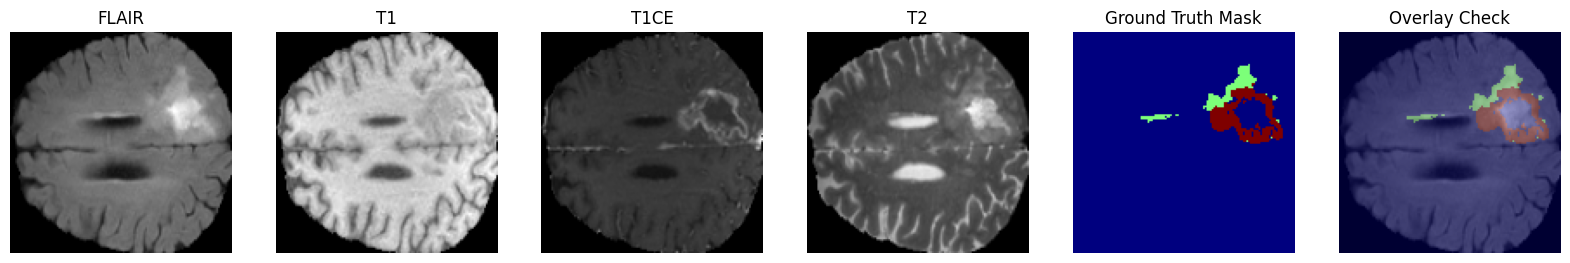

In [8]:
X_batch, y_batch = train_gen[0]
idx = 0

plt.figure(figsize=(20, 5))

titles = ['FLAIR', 'T1', 'T1CE', 'T2']
for i in range(4):
    plt.subplot(1, 6, i+1)
    plt.imshow(X_batch[idx, :, :, i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.subplot(1, 6, 5)
plt.imshow(np.argmax(y_batch[idx], axis=-1), cmap='jet')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(1, 6, 6)
plt.imshow(X_batch[idx, :, :, 0], cmap='gray')
plt.imshow(np.argmax(y_batch[idx], axis=-1), cmap='jet', alpha=0.4)
plt.title("Overlay Check")
plt.axis('off')

plt.show()

--- Batch Statistics ---
Channel FLAIR -> Min: 0.0000, Max: 1.0000, Mean: 0.4330
Channel T1 -> Min: 0.0000, Max: 1.0000, Mean: 0.5576
Channel T1CE -> Min: 0.0000, Max: 1.0000, Mean: 0.3707
Channel T2 -> Min: 0.0000, Max: 1.0000, Mean: 0.3330


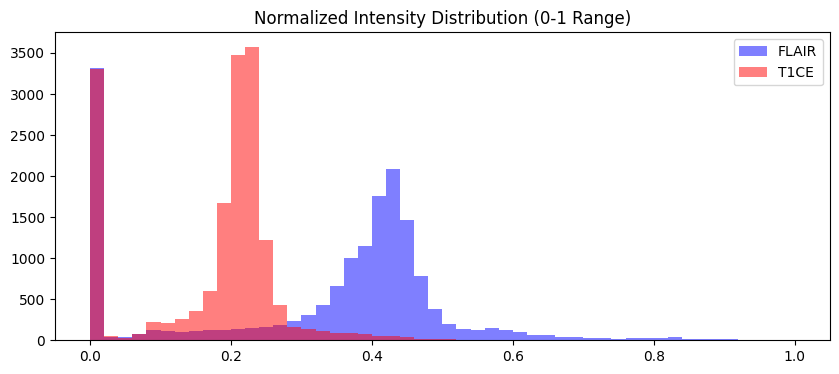

In [9]:
print("--- Batch Statistics ---")
for i in range(4):
    channel_data = X_batch[:, :, :, i]
    print(f"Channel {titles[i]} -> Min: {channel_data.min():.4f}, Max: {channel_data.max():.4f}, Mean: {channel_data.mean():.4f}")

plt.figure(figsize=(10, 4))
plt.hist(X_batch[idx, :, :, 0].flatten(), bins=50, color='blue', alpha=0.5, label='FLAIR')
plt.hist(X_batch[idx, :, :, 2].flatten(), bins=50, color='red', alpha=0.5, label='T1CE')
plt.title("Normalized Intensity Distribution (0-1 Range)")
plt.legend()
plt.show()

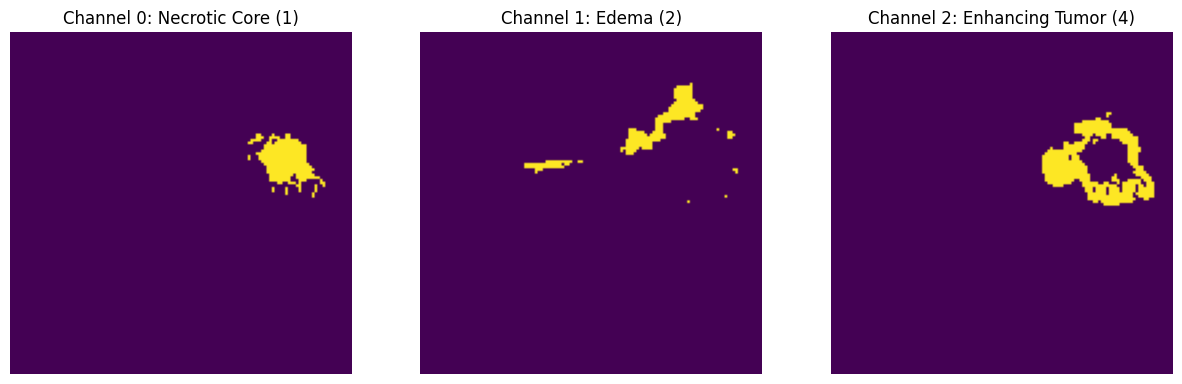

In [10]:
target_regions = ['Necrotic Core (1)', 'Edema (2)', 'Enhancing Tumor (4)']

plt.figure(figsize=(15, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(y_batch[idx, :, :, i], cmap='viridis')
    plt.title(f"Channel {i}: {target_regions[i]}")
    plt.axis('off')
plt.show()

In [16]:
total_patients = len(patient_ids)

train_ids, val_ids, test_ids = split_data(patient_ids)

summary = pd.DataFrame({
    "Subset": ["Train", "Validation", "Test", "Total"],

    "Volumes (Patients)": [
        len(train_ids),
        len(val_ids),
        len(test_ids),
        total_patients
    ],

    "Volume %": [
        round(len(train_ids) / total_patients * 100, 2),
        round(len(val_ids) / total_patients * 100, 2),
        round(len(test_ids) / total_patients * 100, 2),
        100.00
    ],

    "Status": [
        "Ready for Training",
        "Ready for Validation",
        "Ready for Evaluation",
        "Complete Dataset"
    ]
})

display(summary)

NOTEBOOK_PATH = os.path.join(REPO_PATH, "notebooks")

summary_path = os.path.join(NOTEBOOK_PATH, "brats_split_summary.csv")
summary.to_csv(summary_path, index=False)
print(f"Saved summary to: {summary_path}")

,Subset,Volumes (Patients),Volume %,Status
0,Train,265,71.82,Ready for Training
1,Validation,30,8.13,Ready for Validation
2,Test,74,20.05,Ready for Evaluation
3,Total,369,100.00,Complete Dataset


Saved summary to: /content/drive/MyDrive/BraTS_Project/brats-brain-tumor/notebooks/brats_split_summary.csv
